# 06 - Exportacion para Pitch Deck (Final)
## Proyecto Boomerang - SpaceHACK 2026

Genera todas las imagenes con explicaciones claras para las slides y la reunion de equipo.

In [17]:
import ee
import geemap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
import urllib.request

ee.Initialize(project='august-tower-470819-s6')
os.makedirs('../exports', exist_ok=True)

def export_ee_image(image, vis_params, region, filename, dimensions=1024):
    url = image.getThumbURL({**vis_params, 'region': region, 'dimensions': dimensions, 'format': 'png'})
    urllib.request.urlretrieve(url, filename)
    print(f'Exportado: {filename}')

roi = ee.Geometry.Polygon([[
    [-80.23433322304784, -2.581044464678974],
    [-80.09837741250097, -2.581044464678974],
    [-80.09837741250097, -2.4212085241315013],
    [-80.23433322304784, -2.4212085241315013],
    [-80.23433322304784, -2.581044464678974]
]])

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi).filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median().clip(roi))

print('Listo')

Listo


In [18]:
# --- 1. IMAGEN SATELITAL RGB ---
export_ee_image(s2, {'bands': ['B4','B3','B2'], 'min': 0, 'max': 3000}, roi, '../exports/rgb_sentinel2_2024.png')
print('Foto real del satelite Sentinel-2 (2024). Se ven los rectangulos de camaroneras rodeando los canales de manglar.')

Exportado: ../exports/rgb_sentinel2_2024.png
Foto real del satelite Sentinel-2 (2024). Se ven los rectangulos de camaroneras rodeando los canales de manglar.


In [19]:
# --- 2. MAPA NDVI ---
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
export_ee_image(ndvi, {'min': -0.1, 'max': 0.8, 'palette': ['red','yellow','green','darkgreen']}, roi, '../exports/ndvi_2024.png')
print('NDVI = salud de la vegetacion. Verde oscuro = manglar sano. Rojo = sin vegetacion (agua, camaroneras, suelo).')

Exportado: ../exports/ndvi_2024.png
NDVI = salud de la vegetacion. Verde oscuro = manglar sano. Rojo = sin vegetacion (agua, camaroneras, suelo).


In [20]:
# --- 3. HEATMAP NDCI (clorofila en el agua) ---
mndwi = s2.normalizedDifference(['B3', 'B11'])
ndvi_mask = s2.normalizedDifference(['B8', 'B4'])
water_mask = mndwi.gt(0.2).And(ndvi_mask.lt(0.3))
ndci = s2.normalizedDifference(['B5', 'B4']).updateMask(water_mask)
export_ee_image(ndci, {'min': -0.1, 'max': 0.2, 'palette': ['0000FF','00FFFF','FFFF00','FF0000']}, roi, '../exports/ndci_heatmap_2024.png')
print('NDCI = clorofila en el agua. Azul = agua limpia. Rojo = agua con muchos nutrientes (riesgo de marea roja).')

Exportado: ../exports/ndci_heatmap_2024.png
NDCI = clorofila en el agua. Azul = agua limpia. Rojo = agua con muchos nutrientes (riesgo de marea roja).


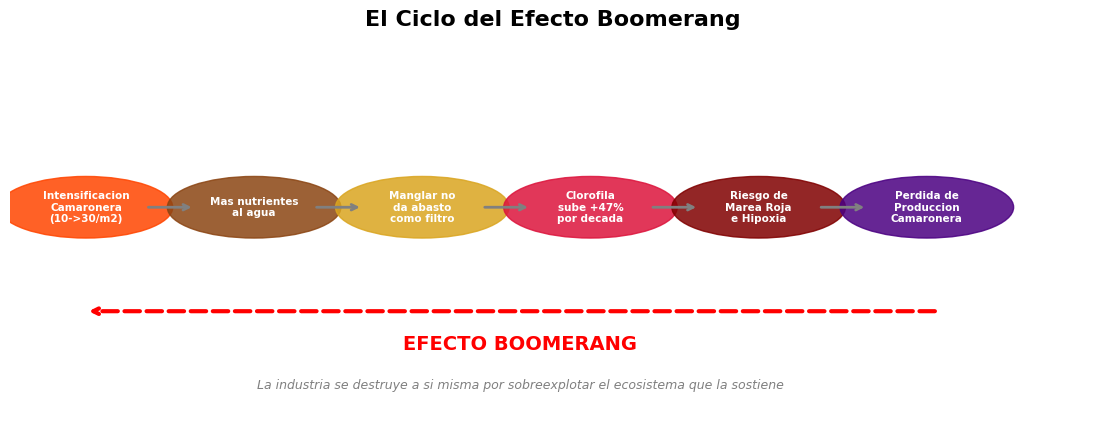

Exportado: boomerang_cycle.png


In [21]:
# --- 4. DIAGRAMA DEL EFECTO BOOMERANG ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

steps = [
    ('Intensificacion\nCamaronera\n(10->30/m2)', '#FF4500'),
    ('Mas nutrientes\nal agua', '#8B4513'),
    ('Manglar no\nda abasto\ncomo filtro', '#DAA520'),
    ('Clorofila\nsube +47%\npor decada', '#DC143C'),
    ('Riesgo de\nMarea Roja\ne Hipoxia', '#800000'),
    ('Perdida de\nProduccion\nCamaronera', '#4B0082'),
]

for i, (label, color) in enumerate(steps):
    x = 0.07 + i * 0.155
    circle = plt.Circle((x, 0.55), 0.08, transform=ax.transAxes, color=color, alpha=0.85)
    ax.add_patch(circle)
    ax.text(x, 0.55, label, ha='center', va='center', fontsize=7.5, color='white', fontweight='bold', transform=ax.transAxes)
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + 0.1, 0.55), xytext=(x + 0.055, 0.55),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.annotate('', xy=(0.07, 0.28), xytext=(0.855, 0.28),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='red', lw=3, linestyle='dashed'))
ax.text(0.47, 0.18, 'EFECTO BOOMERANG', ha='center', fontsize=14, color='red', fontweight='bold', transform=ax.transAxes)
ax.text(0.47, 0.08, 'La industria se destruye a si misma por sobreexplotar el ecosistema que la sostiene',
        ha='center', fontsize=9, color='gray', style='italic', transform=ax.transAxes)

ax.set_title('El Ciclo del Efecto Boomerang', fontsize=16, fontweight='bold')
plt.savefig('../exports/boomerang_cycle.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Exportado: boomerang_cycle.png')

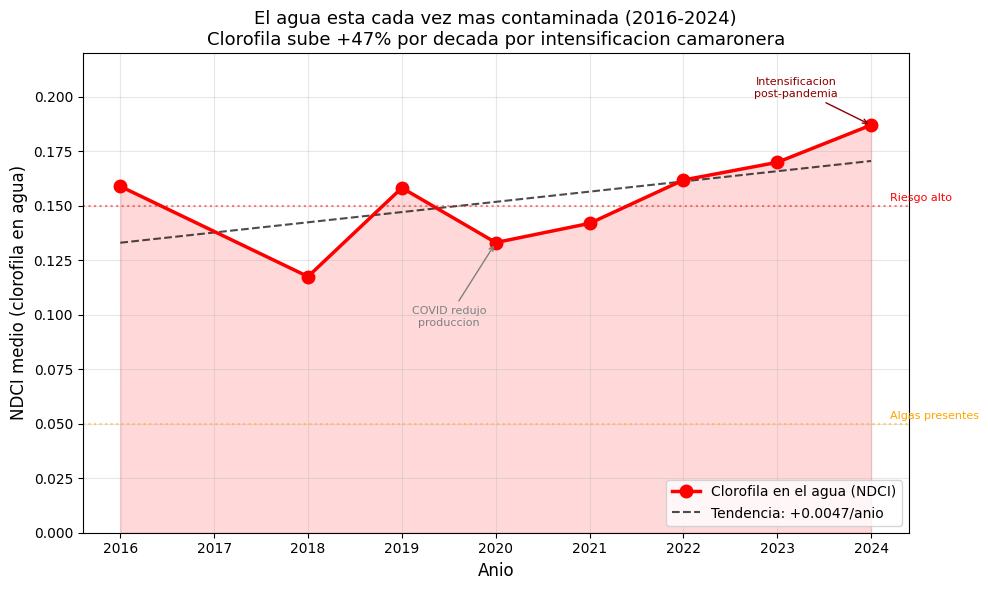

Exportado: ndci_temporal.png


In [22]:
# --- 5. GRAFICA NDCI TEMPORAL (clorofila subiendo) ---
# Datos del notebook 03 (copiar aqui los resultados)
ndci_years = [2016, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
ndci_means = [0.1589, 0.1175, 0.1582, 0.1331, 0.1419, 0.1618, 0.1699, 0.1870]

from scipy import stats as sp_stats
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(ndci_years, ndci_means)
trend = [slope * y + intercept for y in ndci_years]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ndci_years, ndci_means, 'r-o', linewidth=2.5, markersize=9, label='Clorofila en el agua (NDCI)', zorder=3)
ax.fill_between(ndci_years, ndci_means, alpha=0.15, color='red')
ax.plot(ndci_years, trend, 'k--', alpha=0.7, linewidth=1.5, label=f'Tendencia: +{slope:.4f}/anio')

ax.axhline(y=0.05, color='orange', linestyle=':', alpha=0.5)
ax.axhline(y=0.15, color='red', linestyle=':', alpha=0.5)
ax.text(2024.2, 0.052, 'Algas presentes', fontsize=8, color='orange')
ax.text(2024.2, 0.152, 'Riesgo alto', fontsize=8, color='red')

ax.annotate('COVID redujo\nproduccion', xy=(2020, 0.133), xytext=(2019.5, 0.095),
            fontsize=8, color='gray', arrowprops=dict(arrowstyle='->', color='gray'),
            ha='center')
ax.annotate('Intensificacion\npost-pandemia', xy=(2024, 0.187), xytext=(2023.2, 0.20),
            fontsize=8, color='darkred', arrowprops=dict(arrowstyle='->', color='darkred'),
            ha='center')

ax.set_xlabel('Anio', fontsize=12)
ax.set_ylabel('NDCI medio (clorofila en agua)', fontsize=12)
ax.set_title('El agua esta cada vez mas contaminada (2016-2024)\nClorofila sube +47% por decada por intensificacion camaronera', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.22)

plt.tight_layout()
plt.savefig('../exports/ndci_temporal.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Exportado: ndci_temporal.png')

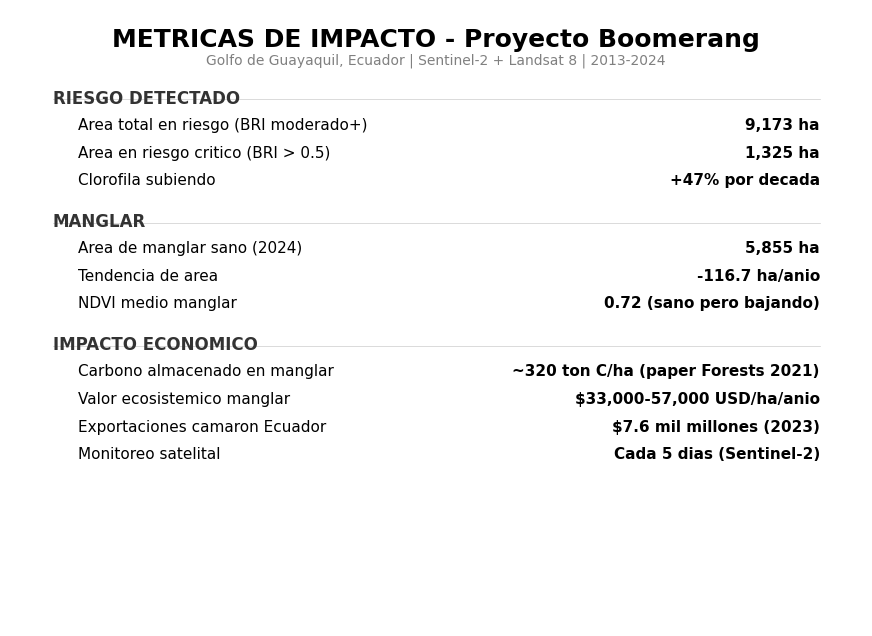

Exportado: impact_metrics.png


In [23]:
# --- 6. PANEL DE METRICAS (datos reales actualizados) ---
fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')

ax.text(0.5, 0.97, 'METRICAS DE IMPACTO - Proyecto Boomerang', fontsize=18, fontweight='bold',
        ha='center', va='top', transform=ax.transAxes)
ax.text(0.5, 0.93, 'Golfo de Guayaquil, Ecuador | Sentinel-2 + Landsat 8 | 2013-2024',
        fontsize=10, color='gray', ha='center', va='top', transform=ax.transAxes)

metrics = [
    ('RIESGO DETECTADO', '', True),
    ('Area total en riesgo (BRI moderado+)', '9,173 ha', False),
    ('Area en riesgo critico (BRI > 0.5)', '1,325 ha', False),
    ('Clorofila subiendo', '+47% por decada', False),
    ('', '', False),
    ('MANGLAR', '', True),
    ('Area de manglar sano (2024)', '5,855 ha', False),
    ('Tendencia de area', '-116.7 ha/anio', False),
    ('NDVI medio manglar', '0.72 (sano pero bajando)', False),
    ('', '', False),
    ('IMPACTO ECONOMICO', '', True),
    ('Carbono almacenado en manglar', '~320 ton C/ha (paper Forests 2021)', False),
    ('Valor ecosistemico manglar', '$33,000-57,000 USD/ha/anio', False),
    ('Exportaciones camaron Ecuador', '$7.6 mil millones (2023)', False),
    ('Monitoreo satelital', 'Cada 5 dias (Sentinel-2)', False),
]

y = 0.87
for label, value, is_header in metrics:
    if is_header:
        ax.text(0.05, y, label, fontsize=12, fontweight='bold', color='#333333',
                transform=ax.transAxes, va='top')
        ax.plot([0.05, 0.95], [y - 0.015, y - 0.015], transform=ax.transAxes, color='#cccccc', linewidth=0.5)
        y -= 0.045
    elif label == '':
        y -= 0.02
    else:
        ax.text(0.08, y, label, fontsize=11, transform=ax.transAxes, va='top')
        ax.text(0.95, y, value, fontsize=11, fontweight='bold', transform=ax.transAxes, va='top', ha='right')
        y -= 0.045

plt.savefig('../exports/impact_metrics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Exportado: impact_metrics.png')

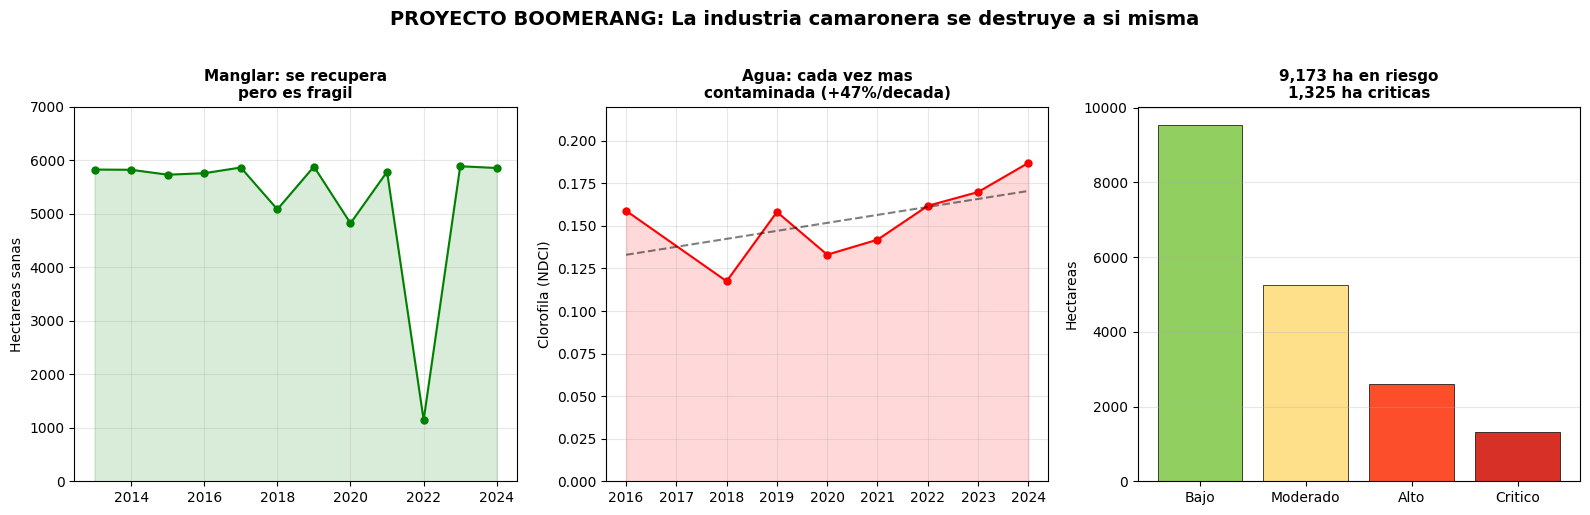

Exportado: resumen_visual.png


In [24]:
# --- 7. RESUMEN VISUAL: La historia completa en una imagen ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Manglar estable
manglar_years = [2013,2014,2015,2016,2017,2018,2019,2020,2021,2023,2024]
manglar_ha = [5826,5822,5730,5758,5864,5082,5881,4822,5785,5888,5855]
axes[0].plot(manglar_years, manglar_ha, 'g-o', markersize=5)
axes[0].fill_between(manglar_years, manglar_ha, alpha=0.15, color='green')
axes[0].set_title('Manglar: se recupera\npero es fragil', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Hectareas sanas')
axes[0].set_ylim(0, 7000)
axes[0].grid(True, alpha=0.3)

# Panel 2: Clorofila subiendo
axes[1].plot(ndci_years, ndci_means, 'r-o', markersize=5)
axes[1].fill_between(ndci_years, ndci_means, alpha=0.15, color='red')
axes[1].plot(ndci_years, trend, 'k--', alpha=0.5)
axes[1].set_title('Agua: cada vez mas\ncontaminada (+47%/decada)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Clorofila (NDCI)')
axes[1].set_ylim(0, 0.22)
axes[1].grid(True, alpha=0.3)

# Panel 3: BRI distribucion
categories = ['Bajo', 'Moderado', 'Alto', 'Critico']
areas_bri = [9550, 5247, 2601, 1325]
colors_bri = ['#91cf60', '#fee08b', '#fc4e2a', '#d73027']
axes[2].bar(categories, areas_bri, color=colors_bri, edgecolor='black', linewidth=0.5)
axes[2].set_title('9,173 ha en riesgo\n1,325 ha criticas', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Hectareas')
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('PROYECTO BOOMERANG: La industria camaronera se destruye a si misma', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../exports/resumen_visual.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Exportado: resumen_visual.png')

In [25]:
# --- LISTA DE ARCHIVOS ---
export_dir = '../exports'
print('=== ARCHIVOS EXPORTADOS ===')
for f in sorted(os.listdir(export_dir)):
    size = os.path.getsize(os.path.join(export_dir, f)) / 1024
    print(f'  {f} ({size:.1f} KB)')

print()
print('=== QUE ES CADA IMAGEN ===')
print('  rgb_sentinel2_2024.png   -> Foto real del satelite')
print('  ndvi_2024.png            -> Salud vegetacion (verde=sano, rojo=muerto)')
print('  ndci_heatmap_2024.png    -> Clorofila en agua (azul=limpia, rojo=contaminada)')
print('  ndci_temporal.png        -> GRAFICA CLAVE: clorofila subiendo cada anio')
print('  temporal_manglar.png     -> Manglar en el tiempo (de notebook 04)')
print('  bri_distribution.png     -> Hectareas por nivel de riesgo (de notebook 05)')
print('  boomerang_cycle.png      -> Diagrama del efecto boomerang')
print('  impact_metrics.png       -> Panel de numeros para el jurado')
print('  resumen_visual.png       -> Las 3 graficas juntas (la mas importante)')

=== ARCHIVOS EXPORTADOS ===
  boomerang_cycle.png (85.0 KB)
  impact_metrics.png (110.1 KB)
  ndci_heatmap_2024.png (349.6 KB)
  ndci_temporal.png (104.2 KB)
  ndvi_2024.png (1032.9 KB)
  resumen_visual.png (121.6 KB)
  rgb_sentinel2_2024.png (2341.9 KB)
  v1 (4.0 KB)

=== QUE ES CADA IMAGEN ===
  rgb_sentinel2_2024.png   -> Foto real del satelite
  ndvi_2024.png            -> Salud vegetacion (verde=sano, rojo=muerto)
  ndci_heatmap_2024.png    -> Clorofila en agua (azul=limpia, rojo=contaminada)
  ndci_temporal.png        -> GRAFICA CLAVE: clorofila subiendo cada anio
  temporal_manglar.png     -> Manglar en el tiempo (de notebook 04)
  bri_distribution.png     -> Hectareas por nivel de riesgo (de notebook 05)
  boomerang_cycle.png      -> Diagrama del efecto boomerang
  impact_metrics.png       -> Panel de numeros para el jurado
  resumen_visual.png       -> Las 3 graficas juntas (la mas importante)
